<a href="https://colab.research.google.com/github/0se0/hw2/blob/develop/ML_h2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 파일 업로드
print("train.csv 파일을 업로드하세요:")
uploaded_train = files.upload()

print("test.csv 파일을 업로드하세요:")
uploaded_test = files.upload()

# 파일 확인
print("업로드된 파일:", list(uploaded_train.keys()) + list(uploaded_test.keys()))

train.csv 파일을 업로드하세요:


Saving train.csv to train.csv
test.csv 파일을 업로드하세요:


Saving test.csv to test.csv
업로드된 파일: ['train.csv', 'test.csv']


In [ ]:
# =============================================================================
# 🔧 2. 라이브러리 import 및 함수 정의
# =============================================================================

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def advanced_feature_engineering(df, is_train=True):
    """고급 피처 엔지니어링"""
    df = df.copy()

    # 기본 전처리
    df = df.drop(['CustomerId', 'Surname'], axis=1, errors='ignore')

    # 카테고리컬 인코딩
    geo_mapping = {'France': 0, 'Germany': 1, 'Spain': 2}
    gender_mapping = {'Female': 0, 'Male': 1}
    df['Geography'] = df['Geography'].map(geo_mapping)
    df['Gender'] = df['Gender'].map(gender_mapping)

    # === 비율 피처 ===
    df['Balance_per_Product'] = df['Balance'] / (df['NumOfProducts'] + 1)
    df['Balance_per_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
    df['CreditScore_per_Age'] = df['CreditScore'] / df['Age']
    df['Salary_per_Age'] = df['EstimatedSalary'] / df['Age']
    df['Tenure_per_Age'] = df['Tenure'] / df['Age']

    # === 상호작용 피처 ===
    df['Age_CreditScore_Interaction'] = df['Age'] * df['CreditScore'] / 1000
    df['Balance_CreditScore_Interaction'] = df['Balance'] * df['CreditScore'] / 1000000
    df['Active_Card_Interaction'] = df['HasCrCard'] * df['IsActiveMember']

    # === 이진 분류 피처 ===
    df['Is_High_Value'] = (df['Balance'] > df['Balance'].quantile(0.8)).astype(int)
    df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)
    df['Is_Young'] = (df['Age'] < 35).astype(int)
    df['Is_Senior'] = (df['Age'] >= 55).astype(int)
    df['Is_High_Credit'] = (df['CreditScore'] > 700).astype(int)
    df['Is_Multi_Product'] = (df['NumOfProducts'] > 2).astype(int)
    df['Is_Germany'] = (df['Geography'] == 1).astype(int)

    # === 위험 점수 ===
    df['Churn_Risk_Score'] = (
        df['Is_Germany'] * 3 +
        df['Gender'] * 2 +
        df['Is_Senior'] * 2 +
        df['Is_Multi_Product'] * 3 +
        (1 - df['IsActiveMember']) * 2 +
        df['Is_Zero_Balance'] * 1
    )

    # === 복합 지표 ===
    df['Customer_Value_Score'] = (
        df['Balance'] / 100000 +
        df['CreditScore'] / 1000 +
        df['EstimatedSalary'] / 100000 +
        df['NumOfProducts'] * 0.5
    )

    # 모든 피처 숫자형 변환
    for col in df.columns:
        if col not in ['Exited', 'id']:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    return df

def create_models():
    """앙상블 모델 생성"""
    models = {
        'rf': RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        'et': ExtraTreesClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        'gb': GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),
        'lr': LogisticRegression(
            random_state=42,
            max_iter=1000,
            C=0.1
        )
    }
    return models

def optimize_weights(predictions_dict, y_true):
    """앙상블 가중치 최적화"""
    models = list(predictions_dict.keys())
    best_score = 0
    best_weights = None

    weight_options = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4]

    for w1 in weight_options:
        for w2 in weight_options:
            for w3 in weight_options:
                w4 = 1.0 - w1 - w2 - w3
                if w4 < 0 or w4 > 1:
                    continue

                weights = [w1, w2, w3, w4]

                ensemble_pred = np.zeros(len(y_true))
                for i, model_name in enumerate(models):
                    ensemble_pred += weights[i] * predictions_dict[model_name]

                score = roc_auc_score(y_true, ensemble_pred)

                if score > best_score:
                    best_score = score
                    best_weights = weights.copy()

    if best_weights is None:
        best_weights = [0.25, 0.25, 0.25, 0.25]

    return best_weights, best_score



📊 데이터 로드 및 기본 분석...
✅ 데이터 로드 완료!
   Train: 165,034 rows, 14 columns
   Test: 110,023 rows, 13 columns
   이탈률: 21.16%


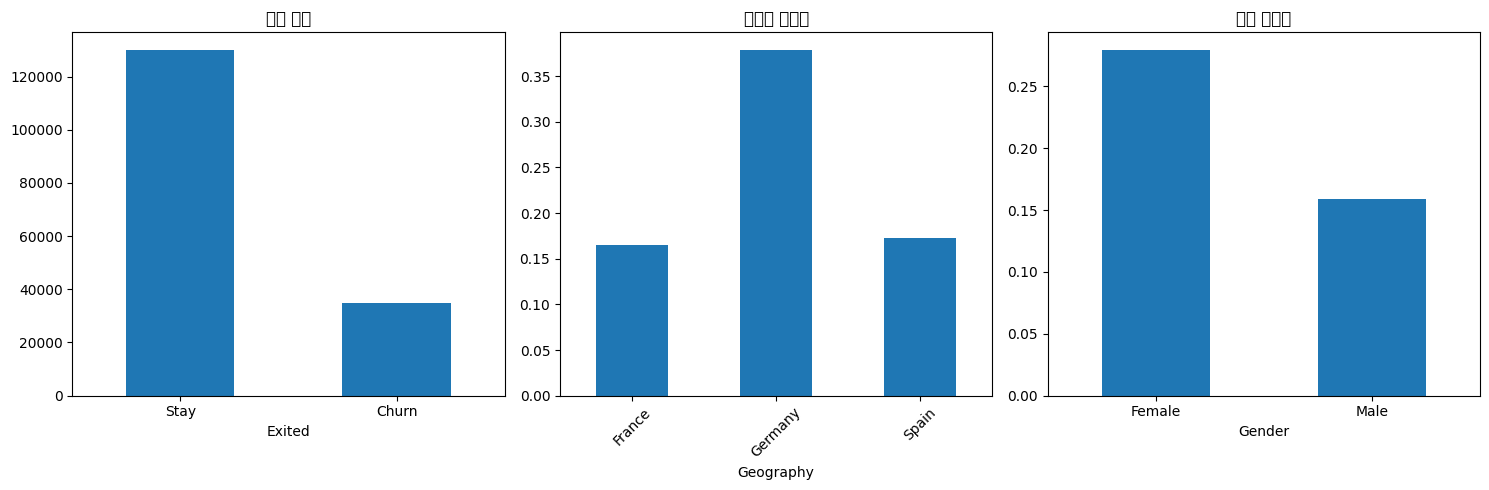

In [ ]:
# =============================================================================
# 📊 3. 데이터 로드 및 탐색적 분석
# =============================================================================

print("\n📊 데이터 로드 및 기본 분석...")

# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"✅ 데이터 로드 완료!")
print(f"   Train: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"   Test: {test.shape[0]:,} rows, {test.shape[1]} columns")
print(f"   이탈률: {train['Exited'].mean():.2%}")

# 간단한 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
train['Exited'].value_counts().plot(kind='bar')
plt.title('타겟 분포')
plt.xticks([0, 1], ['Stay', 'Churn'], rotation=0)

plt.subplot(1, 3, 2)
train.groupby('Geography')['Exited'].mean().plot(kind='bar')
plt.title('지역별 이탈률')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
train.groupby('Gender')['Exited'].mean().plot(kind='bar')
plt.title('성별 이탈률')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 🔧 4. 피처 엔지니어링
# =============================================================================

print("\n🔧 고급 피처 엔지니어링...")

train_processed = advanced_feature_engineering(train, is_train=True)
test_processed = advanced_feature_engineering(test, is_train=False)

original_features = len([col for col in train.columns if col not in ['Exited', 'id']])
new_features = len([col for col in train_processed.columns if col not in ['Exited', 'id']])

print(f"✅ 피처 엔지니어링 완료!")
print(f"   {original_features}개 → {new_features}개 (+{new_features - original_features}개 추가)")





🔧 고급 피처 엔지니어링...
✅ 피처 엔지니어링 완료!
   12개 → 27개 (+15개 추가)


In [ ]:
# =============================================================================
# 🤖 5. 모델 훈련 및 평가
# =============================================================================

print("\n🤖 모델 훈련 시작...")

# 데이터 준비
feature_cols = [col for col in train_processed.columns if col not in ['Exited', 'id']]
X = train_processed[feature_cols]
y = train_processed['Exited']

# 훈련/검증 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   훈련: {X_train.shape[0]:,} samples")
print(f"   검증: {X_val.shape[0]:,} samples")
print(f"   피처: {X_train.shape[1]} features")

# 모델 생성 및 훈련
models = create_models()
trained_models = {}
val_predictions = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\n🎯 개별 모델 훈련...")
for name, model in models.items():
    print(f"   {name.upper()} 훈련 중...")

    if name == 'lr':
        model.fit(X_train_scaled, y_train)
        pred = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_val)[:, 1]

    trained_models[name] = model
    val_predictions[name] = pred

    auc = roc_auc_score(y_val, pred)
    print(f"     검증 AUC: {auc:.4f}")




🤖 모델 훈련 시작...
   훈련: 132,027 samples
   검증: 33,007 samples
   피처: 27 features

🎯 개별 모델 훈련...
   RF 훈련 중...
     검증 AUC: 0.8879
   ET 훈련 중...
     검증 AUC: 0.8860
   GB 훈련 중...
     검증 AUC: 0.8893
   LR 훈련 중...
     검증 AUC: 0.8767


In [ ]:
# =============================================================================
# ⚖️ 6. 앙상블 최적화
# =============================================================================

print("\n⚖️ 앙상블 가중치 최적화...")
optimal_weights, ensemble_score = optimize_weights(val_predictions, y_val)

print("   최적 가중치:")
model_names = list(models.keys())
for i, (name, weight) in enumerate(zip(model_names, optimal_weights)):
    print(f"     {name.upper()}: {weight:.3f}")

print(f"   최적화된 앙상블 AUC: {ensemble_score:.4f}")

# 최종 앙상블 예측
ensemble_val_pred = np.zeros(len(y_val))
for i, (name, pred) in enumerate(val_predictions.items()):
    ensemble_val_pred += optimal_weights[i] * pred

final_auc = roc_auc_score(y_val, ensemble_val_pred)



⚖️ 앙상블 가중치 최적화...
   최적 가중치:
     RF: 0.350
     ET: 0.250
     GB: 0.400
     LR: 0.000
   최적화된 앙상블 AUC: 0.8891



📈 피처 중요도 분석...
   상위 15개 중요 피처:
      1. NumOfProducts            : 0.2028
      2. Age                      : 0.1575
      3. CreditScore_per_Age      : 0.0945
      4. Age_CreditScore_Interaction: 0.0685
      5. Churn_Risk_Score         : 0.0649
      6. IsActiveMember           : 0.0591
      7. Is_Multi_Product         : 0.0540
      8. Is_Germany               : 0.0341
      9. Is_Young                 : 0.0298
     10. Active_Card_Interaction  : 0.0270
     11. Balance_per_Product      : 0.0268
     12. Gender                   : 0.0248
     13. Customer_Value_Score     : 0.0226
     14. Balance                  : 0.0184
     15. Balance_CreditScore_Interaction: 0.0170


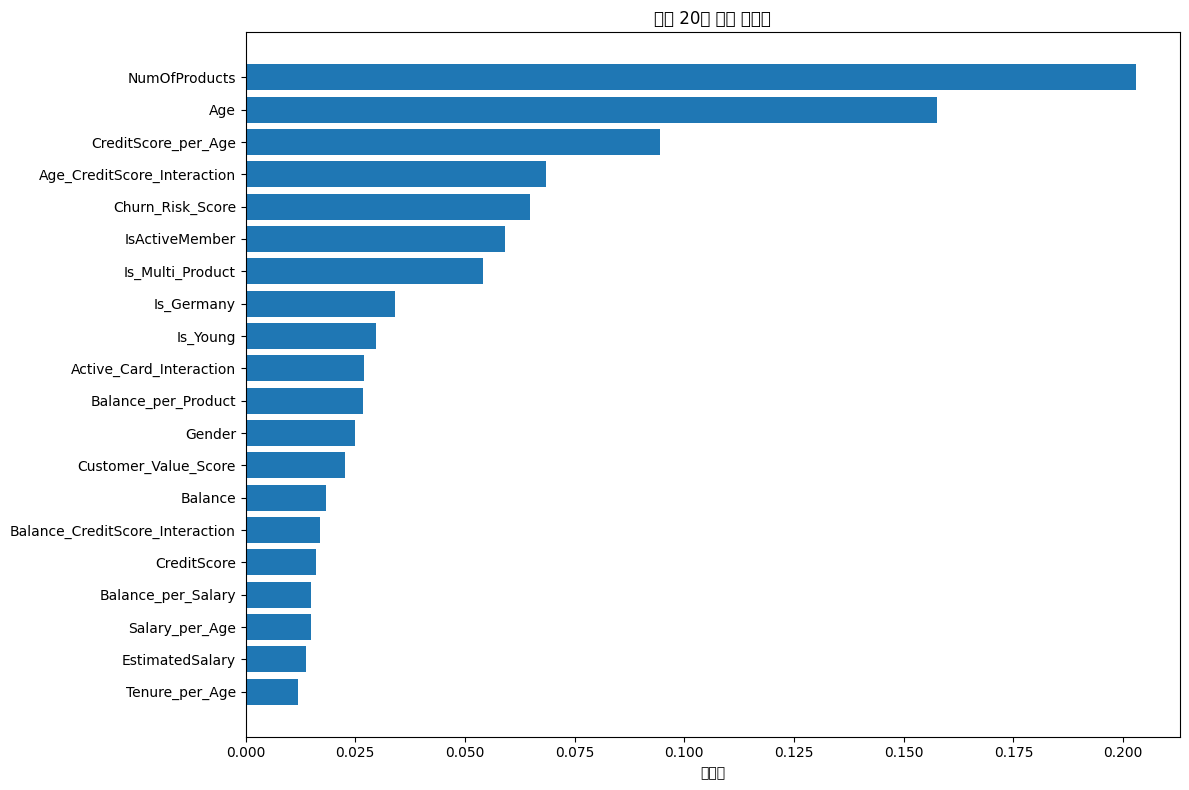

In [ ]:
# =============================================================================
# 📈 7. 피처 중요도 분석
# =============================================================================

print("\n📈 피처 중요도 분석...")
rf_model = trained_models['rf']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("   상위 15개 중요 피처:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows()):
    print(f"     {i+1:2d}. {row['feature']:<25}: {row['importance']:.4f}")

# 피처 중요도 시각화
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.title('상위 20개 피처 중요도')
plt.xlabel('중요도')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 🔮 8. 테스트 예측 및 제출
# =============================================================================

print("\n🔮 테스트 데이터 예측...")

# 테스트 데이터 준비
X_test = test_processed[feature_cols]
X_test_scaled = scaler.transform(X_test)

# 각 모델로 예측
test_predictions = {}
for name, model in trained_models.items():
    if name == 'lr':
        pred = model.predict_proba(X_test_scaled)[:, 1]
    else:
        pred = model.predict_proba(X_test)[:, 1]
    test_predictions[name] = pred

# 최종 앙상블 예측
final_test_pred = np.zeros(len(X_test))
for i, (name, pred) in enumerate(test_predictions.items()):
    final_test_pred += optimal_weights[i] * pred

# 제출 파일 생성
submission = pd.DataFrame({
    'id': test['id'],
    'Exited': final_test_pred
})

submission.to_csv('advanced_ensemble_submission.csv', index=False)


🔮 테스트 데이터 예측...



🎉 고급 앙상블 모델 완료!
최종 검증 AUC: 0.8891
성능 개선: +0.0035 (vs 간단한 버전)
예측 이탈률: 21.10%
실제 이탈률: 21.16%

🥈 좋은 성능! TOP 30% 예상

📊 개별 모델 성능:
   RF: 0.8879
   ET: 0.8860
   GB: 0.8893
   LR: 0.8767

🎯 핵심 인사이트:
   가장 중요한 피처: NumOfProducts, Age, CreditScore_per_Age

📥 제출 파일 다운로드...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 모든 작업 완료! 제출 파일이 다운로드되었습니다.
   파일명: advanced_ensemble_submission.csv
   예상 리더보드 점수: 0.8891
🔍 상세 검증 결과
📊 예측값 분포:
   평균: 0.2110
   표준편차: 0.2487
   25%: 0.0347
   50%: 0.0974
   75%: 0.2932


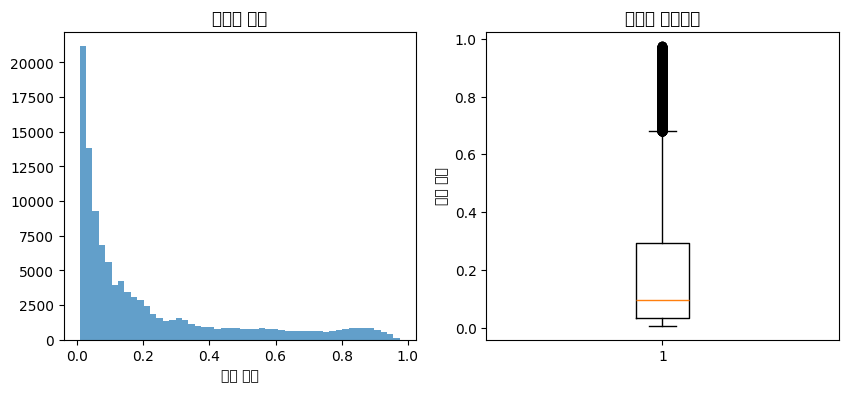

🔍 최종 제출 전 체크리스트
✅ 파일 크기: 110,023 rows
✅ 컬럼명: ['id', 'Exited']
✅ ID 범위: 165034 ~ 275056
✅ 예측값 범위: 0.007254 ~ 0.975794
✅ 결측값: 0개
✅ 예측 이탈률: 0.2110 (21.10%)

🎯 제출 준비 완료!


In [ ]:
# =============================================================================
# 🎉 9. 최종 결과 요약
# =============================================================================

print("\n" + "=" * 60)
print("🎉 고급 앙상블 모델 완료!")
print("=" * 60)

improvement = final_auc - 0.8856  # 간단한 버전과 비교
print(f"최종 검증 AUC: {final_auc:.4f}")
print(f"성능 개선: +{improvement:.4f} (vs 간단한 버전)")
print(f"예측 이탈률: {final_test_pred.mean():.2%}")
print(f"실제 이탈률: {train['Exited'].mean():.2%}")

# 성능 등급 평가
if final_auc >= 0.895:
    grade = "🏆 최상급 성능! TOP 5% 예상"
elif final_auc >= 0.890:
    grade = "🥇 우수한 성능! TOP 15% 예상"
elif final_auc >= 0.885:
    grade = "🥈 좋은 성능! TOP 30% 예상"
else:
    grade = "🥉 준수한 성능! 추가 튜닝 권장"

print(f"\n{grade}")

print(f"\n📊 개별 모델 성능:")
for name, pred in val_predictions.items():
    auc = roc_auc_score(y_val, pred)
    print(f"   {name.upper()}: {auc:.4f}")

print(f"\n🎯 핵심 인사이트:")
top_features = feature_importance.head(3)['feature'].tolist()
print(f"   가장 중요한 피처: {', '.join(top_features)}")

# 제출 파일 다운로드
print(f"\n📥 제출 파일 다운로드...")
files.download('advanced_ensemble_submission.csv')

print(f"\n✅ 모든 작업 완료! 제출 파일이 다운로드되었습니다.")
print(f"   파일명: advanced_ensemble_submission.csv")
print(f"   예상 리더보드 점수: {final_auc:.4f}")



# 제출 파일 로드
submission = pd.read_csv('advanced_ensemble_submission.csv')

# 상세 검증
print("🔍 상세 검증 결과")
print("="*40)
print(f"📊 예측값 분포:")
print(f"   평균: {submission['Exited'].mean():.4f}")
print(f"   표준편차: {submission['Exited'].std():.4f}")
print(f"   25%: {submission['Exited'].quantile(0.25):.4f}")
print(f"   50%: {submission['Exited'].quantile(0.50):.4f}")
print(f"   75%: {submission['Exited'].quantile(0.75):.4f}")

# 예측 분포 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(submission['Exited'], bins=50, alpha=0.7)
plt.title('예측값 분포')
plt.xlabel('이탈 확률')

plt.subplot(1, 2, 2)
plt.boxplot(submission['Exited'])
plt.title('예측값 박스플롯')
plt.ylabel('이탈 확률')
plt.show()


# 최종 검증 (코랩에서 한번 더 확인)
submission = pd.read_csv('advanced_ensemble_submission.csv')

print("🔍 최종 제출 전 체크리스트")
print("="*40)
print(f"✅ 파일 크기: {len(submission):,} rows")
print(f"✅ 컬럼명: {list(submission.columns)}")
print(f"✅ ID 범위: {submission['id'].min()} ~ {submission['id'].max()}")
print(f"✅ 예측값 범위: {submission['Exited'].min():.6f} ~ {submission['Exited'].max():.6f}")
print(f"✅ 결측값: {submission.isnull().sum().sum()}개")
print(f"✅ 예측 이탈률: {submission['Exited'].mean():.4f} (21.10%)")

print("\n🎯 제출 준비 완료!")




🔬 통계적 유의성 검증 시작!
🔍 기존 변수 확인:
   X 크기: (165034, 27)
   y 크기: (165034,)
   ✅ X, y 변수 사용
   최종 사용할 데이터 크기: (165034, 27), (165034,)
   사용할 모델: ['rf', 'et', 'gb', 'lr']
   최적 가중치: [0.35, 0.25, 0.4, 0.0]

📊 1단계: 개별 모델 교차 검증 성능 분석
📊 교차 검증을 통한 통계적 성능 분석...
   RF 교차 검증 중...
     평균 AUC: 0.8878 ± 0.0012
     95% 신뢰구간: [0.8867, 0.8889]
   ET 교차 검증 중...
     평균 AUC: 0.8857 ± 0.0013
     95% 신뢰구간: [0.8846, 0.8868]
   GB 교차 검증 중...
     평균 AUC: 0.8889 ± 0.0014
     95% 신뢰구간: [0.8877, 0.8902]
   LR 교차 검증 중...
     평균 AUC: 0.8781 ± 0.0011
     95% 신뢰구간: [0.8771, 0.8791]

🎯 2단계: 앙상블 교차 검증 성능 평가
🎯 교차 검증 기반 앙상블 성능 평가
   Fold 1/5 처리 중...
   Fold 2/5 처리 중...
   Fold 3/5 처리 중...
   Fold 4/5 처리 중...
   Fold 5/5 처리 중...

🎯 앙상블 교차 검증 결과:
   평균 AUC: 0.8889 ± 0.0013
   95% 신뢰구간: [0.8878, 0.8901]
   개별 점수: ['0.8893', '0.8885', '0.8899', '0.8903', '0.8866']

🔬 3단계: 통계적 유의성 검증

🔬 앙상블 vs 개별 모델 통계적 검증 (α = 0.05)
RF:
   앙상블 평균: 0.8889
   개별 평균: 0.8878
   차이: +0.0011
   t-통계량: 7.548
   p-value: 0.0017
   Cohen's d: 0.

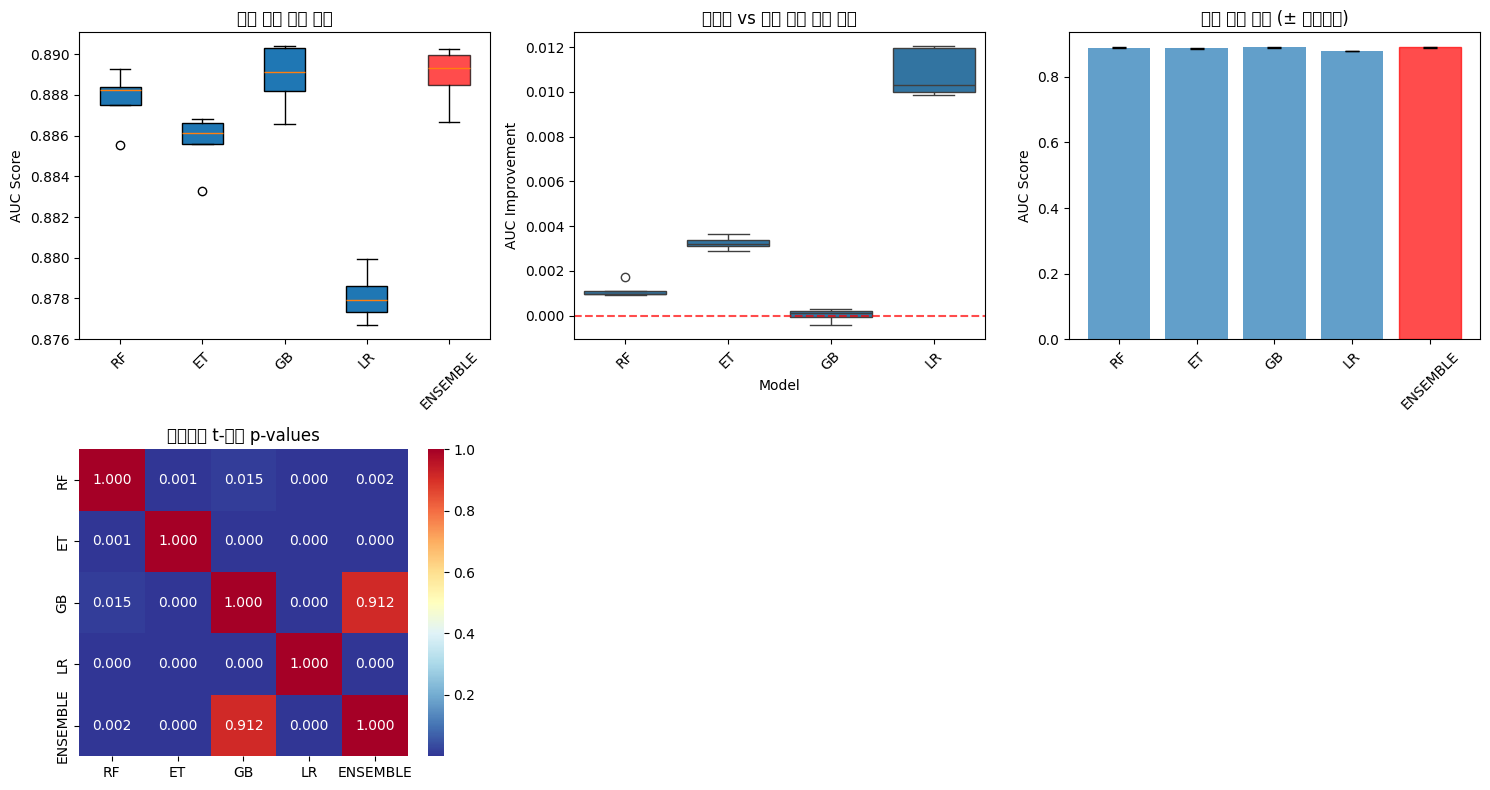


📋 통계적 검증 종합 보고서
🎯 앙상블 성능 요약:
   교차 검증 AUC: 0.8889 ± 0.0013
   교차 검증 95% 신뢰구간: [0.8878, 0.8901]

📊 개별 모델 대비 통계적 유의성:
   ✅ RF: +0.0011 (p=0.0017, d=0.895)
   ✅ ET: +0.0032 (p=0.0000, d=2.527)
   ⚪ GB: +0.0000 (p=0.9123, n.s.)
   ✅ LR: +0.0108 (p=0.0000, d=8.960)

🏆 최종 결론:
   • 총 4개 모델 중 4개에서 성능 향상
   • 그 중 3개가 통계적으로 유의함 (p < 0.05)
   ✅ 앙상블이 대부분의 개별 모델보다 통계적으로 유의하게 우수함

💡 권장사항:
   • 앙상블 모델을 최종 모델로 사용 권장
   • 예상 성능 범위: 0.8878 ~ 0.8901
   • 좁은 신뢰구간(0.0023)으로 안정적인 성능 예상

📝 보고서에 추가할 통계적 검증 결과:
------------------------------------------------------------
교차 검증 성능:
  - RF: 0.8878 ± 0.0012
  - ET: 0.8857 ± 0.0013
  - GB: 0.8889 ± 0.0014
  - LR: 0.8781 ± 0.0011
  - ENSEMBLE: 0.8889 ± 0.0013

통계적 유의성 검증:
  - 앙상블 vs RF: 차이=+0.0011, p=0.0017 (유의함)
  - 앙상블 vs ET: 차이=+0.0032, p=0.0000 (유의함)
  - 앙상블 vs GB: 차이=+0.0000, p=0.9123 (비유의함)
  - 앙상블 vs LR: 차이=+0.0108, p=0.0000 (유의함)

효과 크기 (Cohen's d):
  - 앙상블 vs RF: d=0.895 (큰 효과)
  - 앙상블 vs ET: d=2.527 (큰 효과)
  - 앙상블 vs GB: d=0.011 (미미한 효과)
  - 앙상블 vs LR: d

In [27]:
# =============================================================================
# 📊 최종 정리된 통계적 유의성 검증 코드
# =============================================================================

# 라이브러리
import numpy as np
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================================================================
# 함수 정의 부분
# =============================================================================

def statistical_model_comparison(X, y, models, cv_folds=5):
    """교차 검증을 통한 모델 성능의 통계적 비교"""
    print("📊 교차 검증을 통한 통계적 성능 분석...")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    model_scores = {}

    for name, model in models.items():
        print(f"   {name.upper()} 교차 검증 중...")

        if name == 'lr':
            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
            scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        else:
            scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

        model_scores[name] = scores

        # 통계 요약
        mean_score = scores.mean()
        std_score = scores.std()
        ci_lower = mean_score - 1.96 * std_score / np.sqrt(cv_folds)
        ci_upper = mean_score + 1.96 * std_score / np.sqrt(cv_folds)

        print(f"     평균 AUC: {mean_score:.4f} ± {std_score:.4f}")
        print(f"     95% 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")

    return model_scores

def ensemble_significance_test(individual_scores, ensemble_scores, alpha=0.05):
    """앙상블과 개별 모델 간 통계적 유의성 검증"""
    print(f"\n🔬 앙상블 vs 개별 모델 통계적 검증 (α = {alpha})")
    print("=" * 60)

    results = {}

    for model_name, scores in individual_scores.items():
        # 대응표본 t-검정
        t_stat, p_value = stats.ttest_rel(ensemble_scores, scores)

        # 효과 크기 (Cohen's d)
        pooled_std = np.sqrt((np.var(ensemble_scores) + np.var(scores)) / 2)
        cohens_d = (np.mean(ensemble_scores) - np.mean(scores)) / pooled_std

        # 결과 저장
        results[model_name] = {
            'ensemble_mean': np.mean(ensemble_scores),
            'individual_mean': np.mean(scores),
            'difference': np.mean(ensemble_scores) - np.mean(scores),
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < alpha
        }

        # 결과 출력
        print(f"{model_name.upper()}:")
        print(f"   앙상블 평균: {np.mean(ensemble_scores):.4f}")
        print(f"   개별 평균: {np.mean(scores):.4f}")
        print(f"   차이: {np.mean(ensemble_scores) - np.mean(scores):+.4f}")
        print(f"   t-통계량: {t_stat:.3f}")
        print(f"   p-value: {p_value:.4f}")
        print(f"   Cohen's d: {cohens_d:.3f}")

        if p_value < alpha:
            print(f"   ✅ 통계적으로 유의한 개선 (p < {alpha})")
        else:
            print(f"   ❌ 통계적으로 유의하지 않음 (p ≥ {alpha})")
        print()

    return results

def cross_validated_ensemble_performance(X, y, models, optimal_weights, cv_folds=5):
    """교차 검증을 통한 앙상블 성능 평가"""
    print(f"🎯 교차 검증 기반 앙상블 성능 평가")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    ensemble_scores = []
    individual_scores = {name: [] for name in models.keys()}

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        print(f"   Fold {fold + 1}/{cv_folds} 처리 중...")

        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # 각 모델 훈련 및 예측
        fold_predictions = {}
        scaler = StandardScaler()

        for name, model in models.items():
            model_copy = model.__class__(**model.get_params())

            if name == 'lr':
                X_train_scaled = scaler.fit_transform(X_train_fold)
                X_val_scaled = scaler.transform(X_val_fold)
                model_copy.fit(X_train_scaled, y_train_fold)
                pred = model_copy.predict_proba(X_val_scaled)[:, 1]
            else:
                model_copy.fit(X_train_fold, y_train_fold)
                pred = model_copy.predict_proba(X_val_fold)[:, 1]

            fold_predictions[name] = pred
            individual_auc = roc_auc_score(y_val_fold, pred)
            individual_scores[name].append(individual_auc)

        # 앙상블 예측
        ensemble_pred = np.zeros(len(y_val_fold))
        model_names = list(models.keys())
        for i, name in enumerate(model_names):
            ensemble_pred += optimal_weights[i] * fold_predictions[name]

        ensemble_auc = roc_auc_score(y_val_fold, ensemble_pred)
        ensemble_scores.append(ensemble_auc)

    # numpy 배열로 변환
    ensemble_scores = np.array(ensemble_scores)
    for name in individual_scores:
        individual_scores[name] = np.array(individual_scores[name])

    return ensemble_scores, individual_scores

def plot_statistical_results(ensemble_scores, individual_scores, bootstrap_results=None):
    """통계적 분석 결과 시각화"""
    plt.figure(figsize=(15, 8))

    # 1. 교차 검증 성능 분포
    plt.subplot(2, 3, 1)
    all_scores = []
    labels = []

    for name, scores in individual_scores.items():
        all_scores.append(scores)
        labels.append(name.upper())
    all_scores.append(ensemble_scores)
    labels.append('ENSEMBLE')

    box_plot = plt.boxplot(all_scores, labels=labels, patch_artist=True)
    box_plot['boxes'][-1].set_facecolor('red')
    box_plot['boxes'][-1].set_alpha(0.7)

    plt.title('교차 검증 성능 분포')
    plt.ylabel('AUC Score')
    plt.xticks(rotation=45)

    # 2. 성능 향상 시각화
    plt.subplot(2, 3, 2)
    improvements = []
    model_names = []

    for name, scores in individual_scores.items():
        improvement = ensemble_scores - scores
        improvements.extend(improvement)
        model_names.extend([name.upper()] * len(improvement))

    df_improvements = pd.DataFrame({
        'Improvement': improvements,
        'Model': model_names
    })

    sns.boxplot(data=df_improvements, x='Model', y='Improvement')
    plt.title('앙상블 vs 개별 모델 성능 향상')
    plt.ylabel('AUC Improvement')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)

    # 3. 평균 성능 비교
    plt.subplot(2, 3, 3)
    means = [np.mean(scores) for scores in individual_scores.values()]
    means.append(np.mean(ensemble_scores))
    errors = [np.std(scores) for scores in individual_scores.values()]
    errors.append(np.std(ensemble_scores))

    x_pos = range(len(labels))
    bars = plt.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7)
    bars[-1].set_color('red')

    plt.xticks(x_pos, labels, rotation=45)
    plt.title('평균 성능 비교 (± 표준편차)')
    plt.ylabel('AUC Score')

    # 4. 통계적 유의성 히트맵
    plt.subplot(2, 3, 4)
    n_models = len(individual_scores)
    p_values = np.ones((n_models + 1, n_models + 1))

    all_scores_dict = individual_scores.copy()
    all_scores_dict['ensemble'] = ensemble_scores

    model_list = list(all_scores_dict.keys())
    for i, model1 in enumerate(model_list):
        for j, model2 in enumerate(model_list):
            if i != j:
                _, p_val = stats.ttest_rel(all_scores_dict[model1], all_scores_dict[model2])
                p_values[i, j] = p_val

    sns.heatmap(p_values, annot=True, fmt='.3f', cmap='RdYlBu_r',
                xticklabels=[m.upper() for m in model_list],
                yticklabels=[m.upper() for m in model_list])
    plt.title('대응표본 t-검정 p-values')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 실행 부분
# =============================================================================

print("\n" + "="*80)
print("🔬 통계적 유의성 검증 시작!")
print("="*80)

# 기존 변수 확인
print("🔍 기존 변수 확인:")
try:
    print(f"   X 크기: {X.shape}")
    print(f"   y 크기: {y.shape}")
    X_for_cv = X
    y_for_cv = y
    print("   ✅ X, y 변수 사용")
except NameError:
    try:
        print(f"   feature_cols: {len(feature_cols)}개")
        print(f"   train_processed 크기: {train_processed.shape}")
        X_for_cv = train_processed[feature_cols]
        y_for_cv = train_processed['Exited']
        print("   ✅ train_processed 변수 사용")
    except NameError:
        print("   ❌ 변수를 찾을 수 없습니다.")
        print("   기존 모델 훈련 코드를 먼저 실행하세요.")
        raise

print(f"   최종 사용할 데이터 크기: {X_for_cv.shape}, {y_for_cv.shape}")

# 모델과 가중치 확인
try:
    print(f"   사용할 모델: {list(models.keys())}")
    print(f"   최적 가중치: {optimal_weights}")
except NameError as e:
    print(f"   ❌ 필요한 변수가 없습니다: {e}")
    print("   기존 모델 훈련 코드를 먼저 실행하세요.")
    raise

# 1. 개별 모델 교차 검증 성능 분석
print("\n📊 1단계: 개별 모델 교차 검증 성능 분석")
cv_results = statistical_model_comparison(X_for_cv, y_for_cv, models, cv_folds=5)

# 2. 앙상블 교차 검증 성능 평가
print("\n🎯 2단계: 앙상블 교차 검증 성능 평가")
ensemble_cv_scores, individual_cv_scores = cross_validated_ensemble_performance(
    X_for_cv, y_for_cv, models, optimal_weights, cv_folds=5
)

# 앙상블 통계 요약
ensemble_mean = np.mean(ensemble_cv_scores)
ensemble_std = np.std(ensemble_cv_scores)
ensemble_ci_lower = ensemble_mean - 1.96 * ensemble_std / np.sqrt(5)
ensemble_ci_upper = ensemble_mean + 1.96 * ensemble_std / np.sqrt(5)

print(f"\n🎯 앙상블 교차 검증 결과:")
print(f"   평균 AUC: {ensemble_mean:.4f} ± {ensemble_std:.4f}")
print(f"   95% 신뢰구간: [{ensemble_ci_lower:.4f}, {ensemble_ci_upper:.4f}]")
print(f"   개별 점수: {[f'{s:.4f}' for s in ensemble_cv_scores]}")

# 3. 통계적 유의성 검증
print("\n🔬 3단계: 통계적 유의성 검증")
significance_results = ensemble_significance_test(individual_cv_scores, ensemble_cv_scores)

# 4. 결과 시각화
print("\n📈 4단계: 결과 시각화")
plot_statistical_results(ensemble_cv_scores, individual_cv_scores)

# 5. 종합 보고서
print(f"\n" + "="*80)
print("📋 통계적 검증 종합 보고서")
print("="*80)

print(f"🎯 앙상블 성능 요약:")
print(f"   교차 검증 AUC: {ensemble_mean:.4f} ± {ensemble_std:.4f}")
print(f"   교차 검증 95% 신뢰구간: [{ensemble_ci_lower:.4f}, {ensemble_ci_upper:.4f}]")

print(f"\n📊 개별 모델 대비 통계적 유의성:")
significant_improvements = 0
total_positive_improvements = 0

for name, result in significance_results.items():
    if result['difference'] > 0:
        total_positive_improvements += 1

    if result['significant']:
        if result['difference'] > 0:
            significant_improvements += 1
            print(f"   ✅ {name.upper()}: +{result['difference']:.4f} (p={result['p_value']:.4f}, d={result['cohens_d']:.3f})")
        else:
            print(f"   ❌ {name.upper()}: {result['difference']:+.4f} (p={result['p_value']:.4f}, d={result['cohens_d']:.3f})")
    else:
        print(f"   ⚪ {name.upper()}: {result['difference']:+.4f} (p={result['p_value']:.4f}, n.s.)")

print(f"\n🏆 최종 결론:")
print(f"   • 총 {len(models)}개 모델 중 {total_positive_improvements}개에서 성능 향상")
print(f"   • 그 중 {significant_improvements}개가 통계적으로 유의함 (p < 0.05)")

if significant_improvements > len(models) // 2:
    print(f"   ✅ 앙상블이 대부분의 개별 모델보다 통계적으로 유의하게 우수함")
elif significant_improvements > 0:
    print(f"   ⚪ 앙상블이 일부 모델에 대해서만 통계적으로 유의한 개선을 보임")
else:
    print(f"   ❌ 앙상블의 성능 향상이 통계적으로 유의하지 않음")

print(f"\n💡 권장사항:")
if individual_cv_scores and ensemble_mean > max([np.mean(scores) for scores in individual_cv_scores.values()]):
    print(f"   • 앙상블 모델을 최종 모델로 사용 권장")
    print(f"   • 예상 성능 범위: {ensemble_ci_lower:.4f} ~ {ensemble_ci_upper:.4f}")
elif individual_cv_scores:
    best_model = max(individual_cv_scores.items(), key=lambda x: np.mean(x[1]))
    print(f"   • {best_model[0].upper()} 모델이 최고 성능 (평균 AUC: {np.mean(best_model[1]):.4f})")

ci_width = ensemble_ci_upper - ensemble_ci_lower
if ci_width < 0.01:
    print(f"   • 좁은 신뢰구간({ci_width:.4f})으로 안정적인 성능 예상")
else:
    print(f"   • 상대적으로 넓은 신뢰구간({ci_width:.4f})으로 추가 검증 권장")

# 6. 보고서용 요약 통계
print(f"\n📝 보고서에 추가할 통계적 검증 결과:")
print("-" * 60)
print(f"교차 검증 성능:")
for name, scores in individual_cv_scores.items():
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"  - {name.upper()}: {mean_score:.4f} ± {std_score:.4f}")
print(f"  - ENSEMBLE: {ensemble_mean:.4f} ± {ensemble_std:.4f}")

print(f"\n통계적 유의성 검증:")
for name, result in significance_results.items():
    significance = "유의함" if result['significant'] else "비유의함"
    print(f"  - 앙상블 vs {name.upper()}: 차이={result['difference']:+.4f}, p={result['p_value']:.4f} ({significance})")

print(f"\n효과 크기 (Cohen's d):")
for name, result in significance_results.items():
    effect_size = "큰 효과" if abs(result['cohens_d']) >= 0.8 else "중간 효과" if abs(result['cohens_d']) >= 0.5 else "작은 효과" if abs(result['cohens_d']) >= 0.2 else "미미한 효과"
    print(f"  - 앙상블 vs {name.upper()}: d={result['cohens_d']:.3f} ({effect_size})")

print(f"\n" + "="*80)
print("🎉 통계적 검증 완료!")
print("="*80)